<a href="https://colab.research.google.com/github/alimoorreza/CS181-fall26-notes/blob/main/day10_vision_transformer_ViT_dissection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CS181: Computer Vision, Fall 2026

Thursday, September 24, 2026

📆 [Course Schedule](https://analytics.drake.edu/~reza/teaching/cs181_fall26/cs181_schedule.html) | 📜 [Syllabus](https://analytics.drake.edu/~reza/teaching/cs181_fall26/cs181_syllabus_fall26.pdf)


In [1]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


##**Utility functions**
- Load the mapping between the **class indices and class names** for the 1,000 ImageNet categories.
- Display the **top-5 or top-10 predicted classes** from the 1,000 ImageNet categories.


In [2]:
import torch
import torch.nn as nn
import torchvision
from torchvision import models, transforms, datasets

import sys
import os
import scipy.io

import json
import PIL
import numpy as np
import matplotlib.pyplot as plt

import requests
url = "https://analytics.drake.edu/~reza/teaching/cs181_fall26/datasets/imagenet_1000_classes.json"

response = requests.get(url)
response.raise_for_status()
label_map = response.json()
print(label_map)

def display_prediction(output_prob, label_map, how_many=10):
    print(f"label map: {label_map}")
    '''
    topk          = torch.topk(output_prob, k=how_many)
    topk_prob     = topk.values[0]
    topk_indices  = topk.indices[0]
    '''

    topk            = torch.topk(output_prob, k=how_many, dim=1)
    topk_prob       = topk.values[0]
    topk_indices    = topk.indices[0]


    if device == 'cuda':
        topk_indices  = topk_indices.data.cpu().numpy()
    else:
        topk_indices  = topk_indices.data.numpy()

    print(f"top{how_many}_classes are as follow: \n{topk_indices}")
    labels        = "{:75s}".format("predicted label")
    prob          = "{}".format("probability")
    print("\n{:75s}".format("--------------------------------------------------------------------------------------\n"), labels, prob,"\n{:75s}".format("--------------------------------------------------------------------------------------"))

    for i in range(how_many):
        labels  = label_map[str(topk_indices[i])]
        labels  = "{:75s}".format(labels)
        prob    = "{:.4f}".format(float(topk_prob[i]))
        print(labels, prob)

    print("{:75s}".format("--------------------------------------------------------------------------------------"))


def get_imagenet_mean_std_normalized():
    mean = [0.485, 0.456, 0.406]
    std = [0.229, 0.224, 0.225]
    return mean, std

TEST_IMAGE_DIR  = '/content/drive/MyDrive/cs181_fall26/module_3_classification/images/'
image_name_list = ['random_dog1.jpg',
                   'random_dog2.jpg',
                   'random_cat1.jpg',
                   'random_cat2.jpg',
                   'random_bike1.jpg'
                   ]


{'0': 'tench, Tinca tinca', '1': 'goldfish, Carassius auratus', '2': 'great white shark, white shark, man-eater, man-eating shark, Carcharodon carcharias', '3': 'tiger shark, Galeocerdo cuvieri', '4': 'hammerhead, hammerhead shark', '5': 'electric ray, crampfish, numbfish, torpedo', '6': 'stingray', '7': 'cock', '8': 'hen', '9': 'ostrich, Struthio camelus', '10': 'brambling, Fringilla montifringilla', '11': 'goldfinch, Carduelis carduelis', '12': 'house finch, linnet, Carpodacus mexicanus', '13': 'junco, snowbird', '14': 'indigo bunting, indigo finch, indigo bird, Passerina cyanea', '15': 'robin, American robin, Turdus migratorius', '16': 'bulbul', '17': 'jay', '18': 'magpie', '19': 'chickadee', '20': 'water ouzel, dipper', '21': 'kite', '22': 'bald eagle, American eagle, Haliaeetus leucocephalus', '23': 'vulture', '24': 'great grey owl, great gray owl, Strix nebulosa', '25': 'European fire salamander, Salamandra salamandra', '26': 'common newt, Triturus vulgaris', '27': 'eft', '28': '

# **Creating Vision Transformer (ViT) network architecture**
> ## **Loading model's pretrained weights from PyTorch library**

In [3]:
# You can give any name to your new network, e.g., ViT.
# You should load the pretrained ViT model from torchvision.models.
# This model was trained on over a million real-world images from ImageNet.


class ViT(nn.Module):

    def __init__(self, num_classes, pretrained=True):

        super(ViT, self).__init__()

        # download PyTorch's own implementation of Vision Transformer model trained on ImageNet dataset
        net             = models.vit_b_16(pretrained=True)
        self.net        = net

        '''
        net             = models.vit_b_32(pretrained=True)
        net             = models.vit_l_16(pretrained=True)
        net             = models.vit_l_32(pretrained=True)
        net             = models.vit_h_14(pretrained=True)
        '''

        # IMPORTANT: "If you need to fine-tune this network for your own dataset,
        # the simplest modification is to replace the last layer in self.classifier with
        # the updated ViT has the desired number of output classes: 'num_classes'
        # self.net.heads.head = nn.Linear(768, num_classes) # only this last layer's weights will be trained from scratch



    def forward(self, x):

      #pdb.set_trace()
      print("shape of input: ", x.shape)
      output = self.net(x)
      print("output shape (self.classifier): ", output.shape)
      return output


In [4]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("device = ", device)
number_of_classes = 1000
model             = ViT(number_of_classes)
model.to(device)


device =  cpu


/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ViT_B_16_Weights.IMAGENET1K_V1`. You can also use `weights=ViT_B_16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:02<00:00, 167MB/s]


ViT(
  (net): VisionTransformer(
    (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    (encoder): Encoder(
      (dropout): Dropout(p=0.0, inplace=False)
      (layers): Sequential(
        (encoder_layer_0): EncoderBlock(
          (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (self_attention): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          )
          (dropout): Dropout(p=0.0, inplace=False)
          (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (mlp): MLPBlock(
            (0): Linear(in_features=768, out_features=3072, bias=True)
            (1): GELU(approximate='none')
            (2): Dropout(p=0.0, inplace=False)
            (3): Linear(in_features=3072, out_features=768, bias=True)
            (4): Dropout(p=0.0, inplace=False)
          )
        )
        (encoder_layer_1): EncoderBlock(
          (ln_1): LayerNorm((76

# **Doing single forward pass on Vision Transformer (ViT) using a sample image**

### **Run the pretrained model on a random image to test its classification ability**
> I have uploaded the images of `cat,` `dog,` and `bike` to Blackboard.

> You can download those images and upload them to your workspace. Alternatively, you can download random images of a `cat,` `dog,` or `any other class of your choice` and test them using vggnet.


[width, height] of the image: [1024, 683]


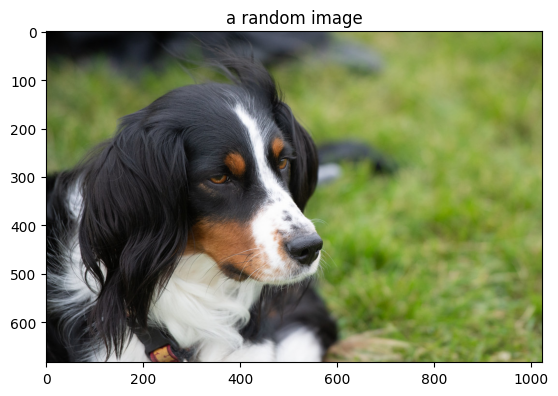

In [5]:
img_index       = 0
img_name        = TEST_IMAGE_DIR + '/' + image_name_list[img_index]

# read the image and display
img             = PIL.Image.open(img_name)
print(f"[width, height] of the image: [{img.size[0]}, {img.size[1]}]")
plt.imshow(img)
plt.title("a random image")
plt.show()


##**Transform the image by resizing + normalizing it with ImageNet mean**
- CNN architectures such as AlexNet, VGGNet, ResNet, and ViT has been pre-trained using the ImageNet dataset.
- You need to normalize each image with the given mean and standard deviation before doing the forward-pass on these networks.
- You can compose resize and normalize operations together using `torchvision.transform` operation



In [8]:
imagenet_mean, imagenet_std  = get_imagenet_mean_std_normalized()
print(f"ImageNet: mean: {imagenet_mean}, std: {imagenet_std}")


TEST_IMAGE_SIZE_W   = 224
TEST_IMAGE_SIZE_H   = 224

# CNN architectures such as AlexNet, VGGNet, and ResNet has been pre-trained using the ImageNet dataset.
# You need to normalize each image with the given mean and standard deviation before doing the forward-pass on these networks.
transform = transforms.Compose([
    transforms.Resize((TEST_IMAGE_SIZE_W, TEST_IMAGE_SIZE_H)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std) # ImageNet: mean (R, G, B) and standard deviation (R, G, B)
])

img_transformed          = transform(img).unsqueeze(0).to(device)
print(f"Convert the image into PyTorch tensor after normalization: ...")
print(f"image tensor shape: {img_transformed.shape}") # [HOW_MANY_TENSORS, CHANNEL_SIZE, HEIGHT, WIDTH]
print(f"{"HOW_MANY_TENSORS:":<20} {img_transformed.shape[0]}")
print(f"{"CHANNEL_SIZE:":<20} {img_transformed.shape[1]}")
print(f"{"HEIGHT_SIZE:":<20} {img_transformed.shape[2]}")
print(f"{"WIDTH_SIZE:":<20} {img_transformed.shape[3]}")
print(f"Summary: [how_many, channel, height, width] of the image tensor: {img_transformed.shape[0]}x{img_transformed.shape[1]}x{img_transformed.shape[2]}x{img_transformed.shape[3]}")



ImageNet: mean: [0.485, 0.456, 0.406], std: [0.229, 0.224, 0.225]
Convert the image into PyTorch tensor after normalization: ...
image tensor shape: torch.Size([1, 3, 224, 224])
HOW_MANY_TENSORS:    1
CHANNEL_SIZE:        3
HEIGHT_SIZE:         224
WIDTH_SIZE:          224
Summary: [how_many, channel, height, width] of the image tensor: 1x3x224x224


## **Perform a forward pass of the input volume through your ViT.**

In [9]:
# forward pass the transformed image through your CNN network
model.eval()       # put the model in evaluation mode to get consistent output
raw_output = model(img_transformed)
output_probability = torch.softmax( raw_output, dim=1 )


shape of input:  torch.Size([1, 3, 224, 224])
output shape (self.classifier):  torch.Size([1, 1000])


In [10]:
tmp = output_probability.cpu().detach().numpy()
print(f"Sum of all predicted probabilities: {np.sum(tmp)}")
print(f"Probability of class-0: {tmp[0][0]}")
print(f"Probability of class-1: {tmp[0][1]}")

Sum of all predicted probabilities: 1.0
Probability of class-0: 0.000132411572849378
Probability of class-1: 0.00020550028420984745


### **Identifying the predicted label from the list of 1,000 predefined ImageNet classes.**
- Our forward pass of the input volume through ViT will produce a prediction corresponding to one of these 1,000 classes. We need to map the predicted class index to the appropriate ImageNet class name.**

label map: {'0': 'tench, Tinca tinca', '1': 'goldfish, Carassius auratus', '2': 'great white shark, white shark, man-eater, man-eating shark, Carcharodon carcharias', '3': 'tiger shark, Galeocerdo cuvieri', '4': 'hammerhead, hammerhead shark', '5': 'electric ray, crampfish, numbfish, torpedo', '6': 'stingray', '7': 'cock', '8': 'hen', '9': 'ostrich, Struthio camelus', '10': 'brambling, Fringilla montifringilla', '11': 'goldfinch, Carduelis carduelis', '12': 'house finch, linnet, Carpodacus mexicanus', '13': 'junco, snowbird', '14': 'indigo bunting, indigo finch, indigo bird, Passerina cyanea', '15': 'robin, American robin, Turdus migratorius', '16': 'bulbul', '17': 'jay', '18': 'magpie', '19': 'chickadee', '20': 'water ouzel, dipper', '21': 'kite', '22': 'bald eagle, American eagle, Haliaeetus leucocephalus', '23': 'vulture', '24': 'great grey owl, great gray owl, Strix nebulosa', '25': 'European fire salamander, Salamandra salamandra', '26': 'common newt, Triturus vulgaris', '27': 'ef

/tmp/ipykernel_2335/2004839830.py:49: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  prob    = "{:.4f}".format(float(topk_prob[i]))


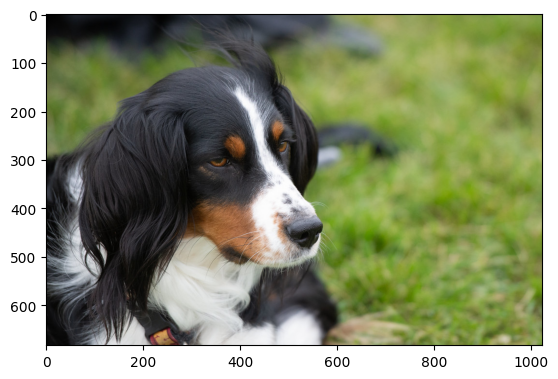

In [11]:
# results after the completion of the forward pass through ViT
#print(f"raw probability: {output_prob}")
display_prediction(output_probability, label_map, how_many=10)
plt.imshow(img)

##**To summarize**
- **you need to do the following steps to pass an input through a pretrained model like ViT and observe the classification label with probabilities as follows:**

input image.shape=torch.Size([1, 3, 224, 224])
shape of input:  torch.Size([1, 3, 224, 224])
output shape (self.classifier):  torch.Size([1, 1000])
label map: {'0': 'tench, Tinca tinca', '1': 'goldfish, Carassius auratus', '2': 'great white shark, white shark, man-eater, man-eating shark, Carcharodon carcharias', '3': 'tiger shark, Galeocerdo cuvieri', '4': 'hammerhead, hammerhead shark', '5': 'electric ray, crampfish, numbfish, torpedo', '6': 'stingray', '7': 'cock', '8': 'hen', '9': 'ostrich, Struthio camelus', '10': 'brambling, Fringilla montifringilla', '11': 'goldfinch, Carduelis carduelis', '12': 'house finch, linnet, Carpodacus mexicanus', '13': 'junco, snowbird', '14': 'indigo bunting, indigo finch, indigo bird, Passerina cyanea', '15': 'robin, American robin, Turdus migratorius', '16': 'bulbul', '17': 'jay', '18': 'magpie', '19': 'chickadee', '20': 'water ouzel, dipper', '21': 'kite', '22': 'bald eagle, American eagle, Haliaeetus leucocephalus', '23': 'vulture', '24': 'great g

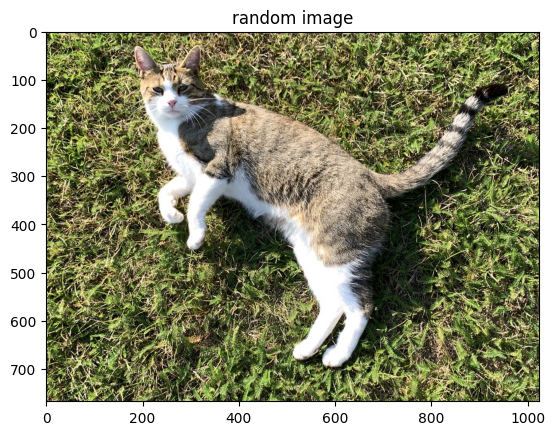

In [17]:
# ------------------------Make a class the load pretrained weights of the transformer ViT------------------------------------------------
num_of_classes = 1000
model = ViT(num_of_classes)
model.to(device)

# ------------------------Read an image using PIL------------------------------------------------
img_index       = 3
img_name        = TEST_IMAGE_DIR + '/' + image_name_list[img_index]
img = PIL.Image.open(img_name)
plt.imshow(img)
plt.title("random image")

# ------------------------Transform the image by resizing + normalizing -------------------------
imagenet_mean, imagenet_std = get_imagenet_mean_std_normalized()
my_transform = transforms.Compose(
    [ transforms.Resize( (224, 224) ),
      transforms.ToTensor(),
      transforms.Normalize(mean=imagenet_mean, std=imagenet_std)]
)
img_transformed = my_transform(img).unsqueeze(0).to(device)
print(f"input image.shape={img_transformed.shape}")

# ------------------------Apply forward pass through your Transformer-----------------------------------------
model.eval()
raw_output = model(img_transformed)
output_prob = torch.softmax( raw_output, dim=1 )
display_prediction(output_prob, label_map, how_many=7)

#**Group task#1**
> **Task#1: Try at least one more variant of the ViT pretrained model from torchvision.**
>> [Reference ViT-Base: vit_b_32]()

>> [Reference ViT-Large: vit_l_16]()

>> [Reference ViT-Large: vit_l_32]()



In [ ]:
# your network code
# ...
# ...
# ...

> ### **Task 2: Run the pretrained model on a random image to test its classification ability**

> Essentially, repeat the experiment we did earlier.


In [ ]:
# your remaining code for forward pass
# ...
# ...
# ...




> ### **Task 3: Summarize your observations and discuss them with your group members.**

>> Is it doing better than `vit_b_16()` model?



##**your answer**


#**Group task#2**
> ### **How would you modify your ViT so that it can fine-tuned for 21 class classification problem?**

>> Hint: you may need to replace the last layer of your `self.net.heads.head` with a `nn.Linear()`

>> only this last layer's weights will be trained from scratch

In [ ]:
# your network code
# ...
# ...
# ...

device =  cpu


/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ViT_B_16_Weights.IMAGENET1K_V1`. You can also use `weights=ViT_B_16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ViT(
  (net): VisionTransformer(
    (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    (encoder): Encoder(
      (dropout): Dropout(p=0.0, inplace=False)
      (layers): Sequential(
        (encoder_layer_0): EncoderBlock(
          (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (self_attention): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          )
          (dropout): Dropout(p=0.0, inplace=False)
          (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (mlp): MLPBlock(
            (0): Linear(in_features=768, out_features=3072, bias=True)
            (1): GELU(approximate='none')
            (2): Dropout(p=0.0, inplace=False)
            (3): Linear(in_features=3072, out_features=768, bias=True)
            (4): Dropout(p=0.0, inplace=False)
          )
        )
        (encoder_layer_1): EncoderBlock(
          (ln_1): LayerNorm((76

shape of input:  torch.Size([1, 3, 224, 224])
output shape (self.classifier):  torch.Size([1, 21])
Sum of all predicted probabilities: 1.0
Probability of class-0: 0.04200541973114014
label map: {'0': 'tench, Tinca tinca', '1': 'goldfish, Carassius auratus', '2': 'great white shark, white shark, man-eater, man-eating shark, Carcharodon carcharias', '3': 'tiger shark, Galeocerdo cuvieri', '4': 'hammerhead, hammerhead shark', '5': 'electric ray, crampfish, numbfish, torpedo', '6': 'stingray', '7': 'cock', '8': 'hen', '9': 'ostrich, Struthio camelus', '10': 'brambling, Fringilla montifringilla', '11': 'goldfinch, Carduelis carduelis', '12': 'house finch, linnet, Carpodacus mexicanus', '13': 'junco, snowbird', '14': 'indigo bunting, indigo finch, indigo bird, Passerina cyanea', '15': 'robin, American robin, Turdus migratorius', '16': 'bulbul', '17': 'jay', '18': 'magpie', '19': 'chickadee', '20': 'water ouzel, dipper', '21': 'kite', '22': 'bald eagle, American eagle, Haliaeetus leucocephalu

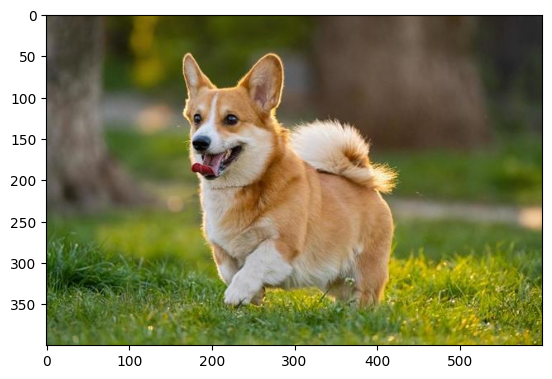

In [ ]:
# remaining forward pass code
# ...
# ...
# ...


#**Group task#3 (optional)**
> ### **Change the network layout to SwinFormer (another variant of Vision Transformer) and rerun the experiment for 1000 class classification problem.**
> [Reference: SwinFormer Tiny](https://pytorch.org/vision/main/models/generated/torchvision.models.swin_v2_t.html#torchvision.models.swin_v2_t)

> Define the network

In [ ]:
# your network code
# ...
# ...
# ...


device =  cpu


SwinFormerTiny(
  (net): SwinTransformer(
    (features): Sequential(
      (0): Sequential(
        (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
        (1): Permute()
        (2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
      )
      (1): Sequential(
        (0): SwinTransformerBlockV2(
          (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
          (attn): ShiftedWindowAttentionV2(
            (qkv): Linear(in_features=96, out_features=288, bias=True)
            (proj): Linear(in_features=96, out_features=96, bias=True)
            (cpb_mlp): Sequential(
              (0): Linear(in_features=2, out_features=512, bias=True)
              (1): ReLU(inplace=True)
              (2): Linear(in_features=512, out_features=3, bias=False)
            )
          )
          (stochastic_depth): StochasticDepth(p=0.0, mode=row)
          (norm2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
          (mlp): MLP(
            (0): Linear(in_featur

> Do the forward pass through SwinFormerTiny using an image

shape of input:  torch.Size([1, 3, 224, 224])
output shape (self.classifier):  torch.Size([1, 1000])
Sum of all predicted probabilities: 0.9999998807907104
Probability of class-0: 8.432809408986941e-05
label map: {'0': 'tench, Tinca tinca', '1': 'goldfish, Carassius auratus', '2': 'great white shark, white shark, man-eater, man-eating shark, Carcharodon carcharias', '3': 'tiger shark, Galeocerdo cuvieri', '4': 'hammerhead, hammerhead shark', '5': 'electric ray, crampfish, numbfish, torpedo', '6': 'stingray', '7': 'cock', '8': 'hen', '9': 'ostrich, Struthio camelus', '10': 'brambling, Fringilla montifringilla', '11': 'goldfinch, Carduelis carduelis', '12': 'house finch, linnet, Carpodacus mexicanus', '13': 'junco, snowbird', '14': 'indigo bunting, indigo finch, indigo bird, Passerina cyanea', '15': 'robin, American robin, Turdus migratorius', '16': 'bulbul', '17': 'jay', '18': 'magpie', '19': 'chickadee', '20': 'water ouzel, dipper', '21': 'kite', '22': 'bald eagle, American eagle, Hali

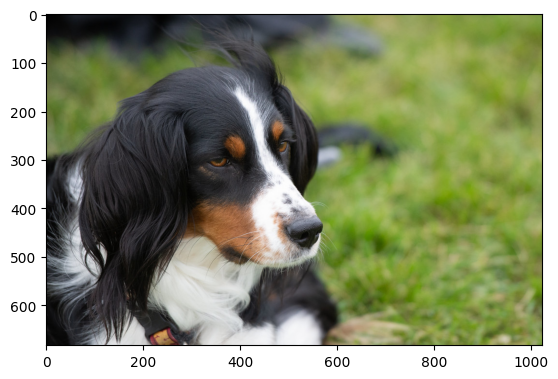

In [ ]:
# your code
# ...
# ...
# ...


#**Group task#4 (optional)**
> ### **How would you modify your SwinFormerTiny so that it can fine-tuned for 21 class classification problem?**

>> Hint: you may need to replace the last layer of your `self.net.heads.head` with a `nn.Linear()`

>> only this last layer's weights will be trained from scratch

In [ ]:
# your code
# ...
# ...
# ...


device =  cpu


SwinFormerTiny(
  (net): SwinTransformer(
    (features): Sequential(
      (0): Sequential(
        (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
        (1): Permute()
        (2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
      )
      (1): Sequential(
        (0): SwinTransformerBlockV2(
          (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
          (attn): ShiftedWindowAttentionV2(
            (qkv): Linear(in_features=96, out_features=288, bias=True)
            (proj): Linear(in_features=96, out_features=96, bias=True)
            (cpb_mlp): Sequential(
              (0): Linear(in_features=2, out_features=512, bias=True)
              (1): ReLU(inplace=True)
              (2): Linear(in_features=512, out_features=3, bias=False)
            )
          )
          (stochastic_depth): StochasticDepth(p=0.0, mode=row)
          (norm2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
          (mlp): MLP(
            (0): Linear(in_featur